# Preprocessat
Primer preprocessem

🧠 1) HOW EVERYTHING RELATES (THE SCHEMA)

Right now you have 3 “layers” of data:

📦 A. Raw images (DICOM files)

Located in:

cbis_ddsm/raw/cbis_ddsm/<FOLDER>/<Study>/<Series>/*.dcm

Each .dcm = one image

📊 B. Case description CSVs (THE IMPORTANT ONES)

You have:

calc_case_description_*
mass_case_description_*

These are your labels + metadata

Each row = one lesion (abnormality)

🔗 C. The link between them (CRUCIAL)

Each row contains:

image file path → original image
cropped image file path → cropped lesion image
ROI mask file path → segmentation mask

👉 These paths map directly to your folders.

🧩 FULL RELATIONSHIP (THIS IS YOUR MENTAL MODEL)
PATIENT (patient_id)
   ↓
STUDY (StudyInstanceUID)
   ↓
SERIES (SeriesInstanceUID)
   ↓
IMAGE (.dcm file)
   ↑
CSV row (labels + metadata)

And more concretely:

CSV row
 ├── pathology → label (BENIGN / MALIGNANT)
 ├── image file path → full mammogram
 ├── cropped image file path → lesion crop
 └── ROI mask file path → segmentation
⚠️ IMPORTANT INSIGHT

👉 You should NOT use the full images first

Use:

cropped image file path (best for classification)
ROI mask file path (for segmentation or attention)

In [18]:
import pandas as pd

mass_train_df = pd.read_csv('data/raw/mass_case_description_train_set.csv')
mass_test_df = pd.read_csv('data/raw/mass_case_description_test_set.csv')
mass_train_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [19]:
calc_train_df = pd.read_csv('data/raw/calc_case_description_train_set.csv')
calc_test_df = pd.read_csv('data/raw/calc_case_description_test_set.csv')
calc_train_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [20]:
metadata_df = pd.read_csv('data/raw/metadata/metadata.csv')
metadata_df.head()

,PatientID,StudyInstanceUID,SeriesInstanceUID,Collection,FileSize,DownloadURL,S5cmdManifestPath,OriginalS5cmdURI,completion_status
0,Calc-Test_P_01004_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.265198230512455509519...,1.3.6.1.4.1.9590.100.1.2.294445047912407030012...,cbis_ddsm,23645061,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,success
1,Calc-Test_P_00038_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.291121996131431385353...,1.3.6.1.4.1.9590.100.1.2.188613955710170417803...,cbis_ddsm,14620630,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,success
2,Calc-Test_P_00041_LEFT_MLO_2,1.3.6.1.4.1.9590.100.1.2.372962290011068589008...,1.3.6.1.4.1.9590.100.1.2.399466258212646932018...,cbis_ddsm,22926678,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,success
3,Calc-Test_P_00038_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.161465562211359959230...,1.3.6.1.4.1.9590.100.1.2.419081637812053404913...,cbis_ddsm,14055890,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,success
4,Calc-Test_P_00485_LEFT_CC_3,1.3.6.1.4.1.9590.100.1.2.188175119112669404616...,1.3.6.1.4.1.9590.100.1.2.284547955212024760928...,cbis_ddsm,24814482,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,success


In [56]:
import pydicom
import numpy as np

def load_dicom(path):
    dcm = pydicom.dcmread(path)
    img = dcm.pixel_array.astype(np.float32)

    # normalize to 0–255
    img = (img - img.min()) / (img.max() - img.min())
    img = (img * 255).astype(np.uint8)

    return img


In [58]:
import os

BASE_PATH = r"C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Transformer\data\raw\cbis_ddsm"

def resolve_dicom_path(rel_path):
    # remove filename (000000.dcm)
    folder = os.path.dirname(rel_path)

    full_folder = os.path.join(BASE_PATH, folder)

    if not os.path.exists(full_folder):
        raise FileNotFoundError(f"Folder not found: {full_folder}")

    # find all .dcm files inside
    dcm_files = [f for f in os.listdir(full_folder) if f.endswith(".dcm")]

    if len(dcm_files) == 0:
        raise FileNotFoundError(f"No DICOM files in {full_folder}")

    if len(dcm_files) > 1:
        print(f"WARNING: Multiple DICOM files in {full_folder}")
        print("Files:", dcm_files)

    # return first one (consistent choice)
    print("ESTHER", full_folder)
    print("ESTHER", dcm_files)
    return os.path.join(full_folder, dcm_files[0])


NameError: name 'img_processed' is not defined

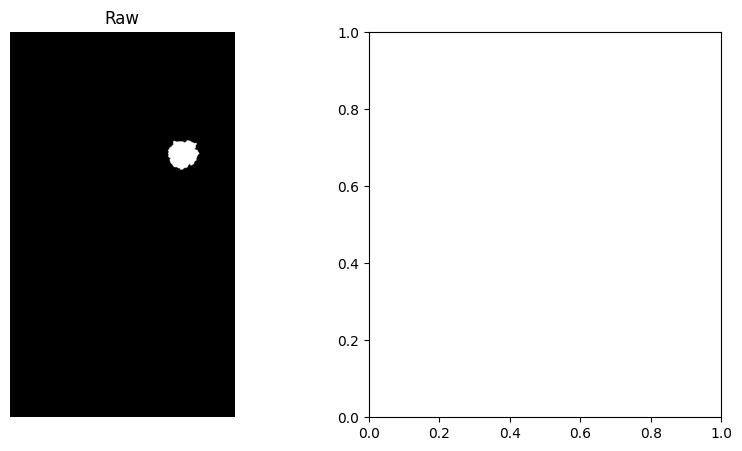

In [ ]:
import matplotlib.pyplot as plt

row = mass_train_df.iloc[0]

#img_path = resolve_dicom_path(row["cropped image file path"])
img_path = "data/raw/cbis_ddsm/AA.AAA/9587fd8e-e6d7-4de0-83c8-d945c6f5330c.dcm"
img_path = "data/raw/cbis_ddsm/Mass-Test_P_01651_RIGHT_CC_1/1.3.6.1.4.1.9590.100.1.2.161262229512414337319591082770840486933/1.3.6.1.4.1.9590.100.1.2.67715339312605506308562264821749036911/64c94beb-9e4f-431b-ab49-9b565d18c13f.dcm"
img_path = "data/raw/cbis_ddsm/Mass-Test_P_01651_RIGHT_CC_1/1.3.6.1.4.1.9590.100.1.2.161262229512414337319591082770840486932/1.3.6.1.4.1.9590.100.1.2.677/64c94beb-9e4f-431b-ab49-9b565d18c13f.dcm"

img_raw = load_dicom(img_path)
label = row["pathology"]  # BENIGN / MALIGNANT

img_raw = load_dicom(img_path)
#img_processed = preprocess(img_raw)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_raw, cmap="gray")
plt.title("Raw")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_processed, cmap="gray")
plt.title("Processed")
plt.axis("off")

plt.show()


In [54]:
import os

print("CWD:", os.getcwd())

CWD: c:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Transformer


In [60]:
import os

BASE_PATH = r"C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Transformer\data\raw\cbis_ddsm"

def resolve_dicom_path(rel_path):
    # normalize CSV path → Windows format
    rel_path = os.path.normpath(rel_path)

    folder = os.path.dirname(rel_path)
    full_folder = os.path.normpath(os.path.join(BASE_PATH, folder))

    if not os.path.exists(full_folder):
        raise FileNotFoundError(f"Folder not found: {full_folder}")

    dcm_files = [f for f in os.listdir(full_folder) if f.endswith(".dcm")]

    if len(dcm_files) == 0:
        raise FileNotFoundError(f"No DICOM files in {full_folder}")

    if len(dcm_files) > 1:
        print(f"⚠️ WARNING: Multiple DICOM files in {full_folder}")
        print("Files:", dcm_files)

    full_path = os.path.normpath(os.path.join(full_folder, dcm_files[0]))

    print("FINAL PATH:", full_path)
    print("EXISTS:", os.path.exists(full_path))

    return full_path


img_path = resolve_dicom_path(row["cropped image file path"])

⚠️ WARNING: Multiple DICOM files in C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Transformer\data\raw\cbis_ddsm\Mass-Training_P_00001_LEFT_CC_1\1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106\1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650
Files: ['692bee15-caa9-4170-84e3-0ef6f9f76959.dcm', '6d322729-239e-4557-911d-7487e6fd0237.dcm']
FINAL PATH: C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Transformer\data\raw\cbis_ddsm\Mass-Training_P_00001_LEFT_CC_1\1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106\1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650\692bee15-caa9-4170-84e3-0ef6f9f76959.dcm
EXISTS: False
